In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [3]:
# 实战训练一对球员数据集实现高维索引操作
# 需求说明
# 加载球员数据集
df=pd.read_csv('../data/player.csv')
# 新增birth列，晚于1987年的球员设置为1，否则设置为0
year=df.birthday.map(lambda x:int(x[0:4]))
df['birth']=np.where(year>1987,1,0)
# 将birth列设置为索引列，并将birth列设置为最高级别索引获取birth索引为1的数据
df=df.set_index(keys=['birth','player_api_id'])
df.loc[1]
# 利用xs()函数获取球员id=162549的数据
df.xs(162549,level=1)
# 获取最高级别的索引值
df.xs(1,level=0)

,player_name,birthday,height,weight
player_api_id,,,,
505942,Aaron Appindangoye,1992-02-29 00:00:00,182.88,187
155782,Aaron Cresswell,1989-12-15 00:00:00,170.18,146
162549,Aaron Doran,1991-05-13 00:00:00,170.18,163
564793,Aaron Kuhl,1996-01-30 00:00:00,172.72,146
528212,Aaron Lennox,1993-02-19 00:00:00,190.50,181
...,...,...,...,...
532766,Zizo,1996-01-10 00:00:00,175.26,148
107281,Zoltan Stieber,1988-10-16 00:00:00,175.26,148
491794,Zoran Josipovic,1995-08-25 00:00:00,187.96,165


,player_name,birthday,height,weight
birth,,,,
1,Aaron Doran,1991-05-13 00:00:00,170.18,163


,player_name,birthday,height,weight
player_api_id,,,,
505942,Aaron Appindangoye,1992-02-29 00:00:00,182.88,187
155782,Aaron Cresswell,1989-12-15 00:00:00,170.18,146
162549,Aaron Doran,1991-05-13 00:00:00,170.18,163
564793,Aaron Kuhl,1996-01-30 00:00:00,172.72,146
528212,Aaron Lennox,1993-02-19 00:00:00,190.50,181
...,...,...,...,...
532766,Zizo,1996-01-10 00:00:00,175.26,148
107281,Zoltan Stieber,1988-10-16 00:00:00,175.26,148
491794,Zoran Josipovic,1995-08-25 00:00:00,187.96,165


In [5]:
# 实战训练--对球员数据集实现分组聚合操作
# 需求说明
# 按照birth分组后实现身高和体重的均值聚合
#     实现分组后身高列的均值聚合
df.groupby(by='birth').height.mean()
#     实现分组后体重列的均值聚合
df.groupby(by='birth').weight.mean()
# 获取分组数据
#     按birth分组后取值为0的分组数据
df.groupby(by='birth').get_group(0)
#     获取按birth分组后取值为1的分组数据信息描述
df.groupby(by='birth').get_group(1)
# 按照birthday列进行分组
#     分组后实现体重列的均值聚合以及按索引的排序操作
df.groupby('birthday').weight.mean().sort_index()

birth
0    182.147417
1    181.557497
Name: height, dtype: float64

birth
0    170.395285
1    166.149552
Name: weight, dtype: float64

player_name             birthday  height  weight
birth player_api_id                                                          
0     30572                Aaron Galindo  1982-05-08 00:00:00  182.88     198
      23780                 Aaron Hughes  1979-11-08 00:00:00  182.88     154
      27316                   Aaron Hunt  1986-09-04 00:00:00  182.88     161
      30895                 Aaron Lennon  1987-04-16 00:00:00  165.10     139
      101042               Aaron Meijers  1987-10-28 00:00:00  175.26     170
...                                  ...                  ...     ...     ...
      26357               Zoumana Camara  1979-04-03 00:00:00  182.88     168
      111182                Zsolt Laczko  1986-12-18 00:00:00  182.88     176
      36491                    Zsolt Low  1979-04-29 00:00:00  180.34     154
      35506          Zurab Khizanishvili  1981-10-06 00:00:00  185.42     172
      39902           Zvjezdan Misimovic  1982-06-05 00:00:00  180.34     176

[5811 rows x 4 columns]

player_name             birthday  height  weight
birth player_api_id                                                         
1     505942         Aaron Appindangoye  1992-02-29 00:00:00  182.88     187
      155782            Aaron Cresswell  1989-12-15 00:00:00  170.18     146
      162549                Aaron Doran  1991-05-13 00:00:00  170.18     163
      564793                 Aaron Kuhl  1996-01-30 00:00:00  172.72     146
      528212               Aaron Lennox  1993-02-19 00:00:00  190.50     181
...                                 ...                  ...     ...     ...
      532766                       Zizo  1996-01-10 00:00:00  175.26     148
      107281             Zoltan Stieber  1988-10-16 00:00:00  175.26     148
      491794            Zoran Josipovic  1995-08-25 00:00:00  187.96     165
      192132         Zouhaier Dhaouadhi  1988-01-01 00:00:00  180.34     159
      282473             Zouhair Feddal  1989-01-01 00:00:00  190.50     172

[5249 rows x 4 columns]

birthday
1967-01-23 00:00:00    161.0
1968-06-26 00:00:00    187.0
1969-01-15 00:00:00    183.0
1969-03-13 00:00:00    174.0
1969-04-01 00:00:00    183.0
                       ...  
1998-12-16 00:00:00    157.0
1998-12-20 00:00:00    148.0
1999-01-23 00:00:00    170.0
1999-02-25 00:00:00    198.0
1999-04-24 00:00:00    141.0
Name: weight, Length: 5762, dtype: float64

<Axes: title={'center': '球员平均身高变化趋势'}, xlabel='birthday'>

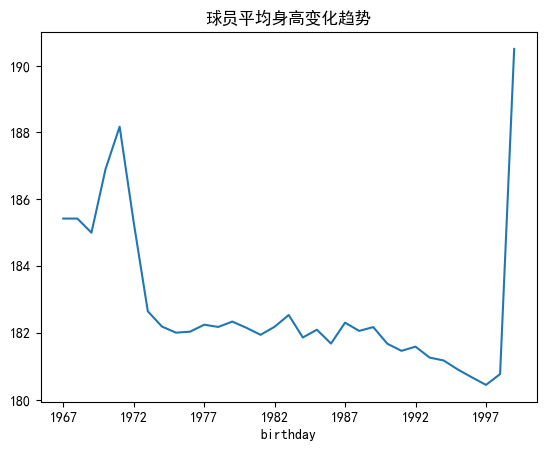

<Axes: title={'center': '佛罗伦萨队各赛季作为主客队进球情况'}, xlabel='season'>

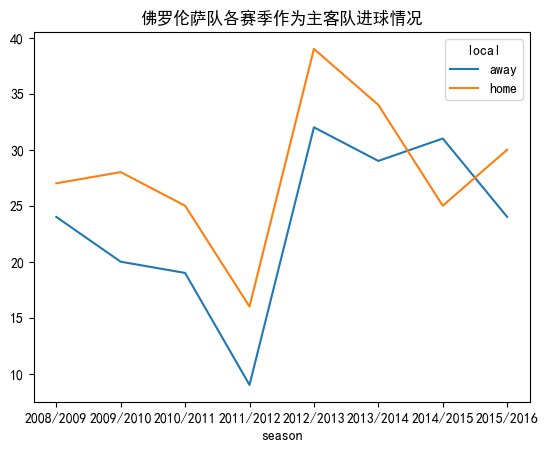

<Axes: title={'center': '佛罗伦萨队各赛季进球总情况'}, xlabel='season'>

<Axes: title={'center': '意甲联赛各队赛季总进球变化趋势'}, xlabel='season'>

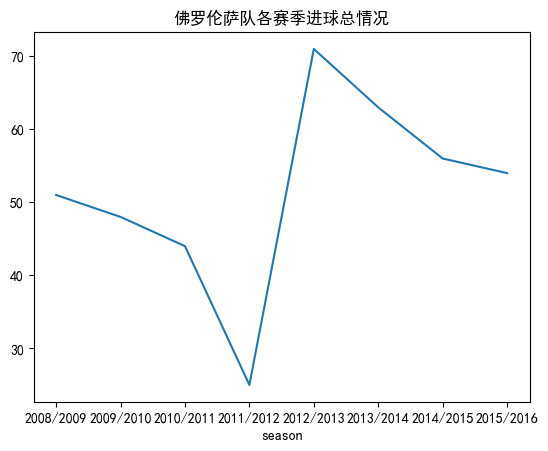

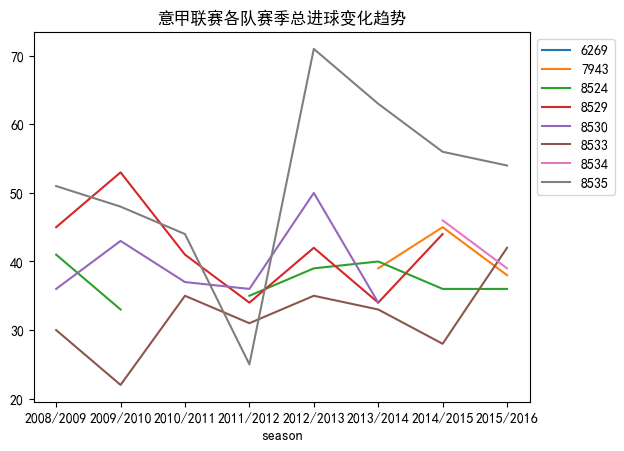

In [7]:
# 实战训练一-折线图在足球数据集中的应用
# 需求说明
df1=pd.read_csv('../data/player.csv')
df2=pd.read_csv('../data/match_goal.csv')
# >不同年出生球员平均身高变化趋势
df1.birthday=df1.birthday.map(lambda x:x[0:4])
df1.groupby('birthday').height.mean().plot(title='球员平均身高变化趋势')
plt.show()
# >佛罗伦萨队(8535)，各赛季作为主队、客队进球的总情况
df2.query('team_api_id==8535').groupby(['season','local']).team_goal.sum().unstack().plot(title='佛罗伦萨队各赛季作为主客队进球情况')
plt.show()
# 佛罗伦萨队(8535)，各赛季总情况
df2.query('team_api_id==8535').groupby('season').team_goal.sum().plot(title='佛罗伦萨队各赛季进球总情况')
# 意甲联赛(10257)各队赛季总进球变化趋势
a=df2.query('league_id==10257').groupby(['team_api_id','season']).team_goal.sum().unstack(level=0)
a.loc[:,6269:8535].plot(title='意甲联赛各队赛季总进球变化趋势')
plt.legend(bbox_to_anchor=(1,1))

<Axes: title={'center': '梅西和C罗各赛季出战情况'}, xlabel='season'>

<Axes: title={'center': '梅西和C罗各赛季出战情况'}, xlabel='season'>

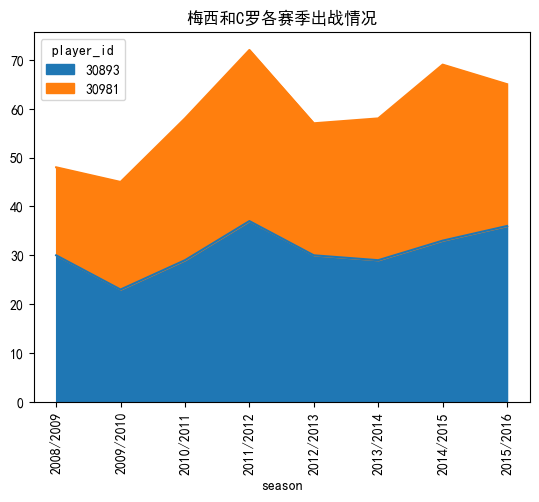

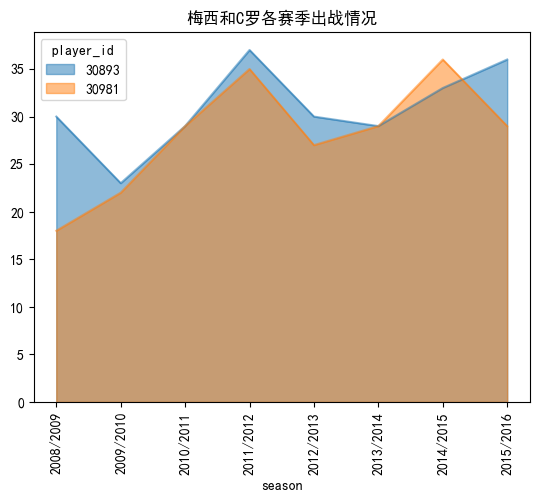

In [9]:
# 实战训练-面积图在足球数据集中的应用
# 需求说明
# 利用面积图统计梅西(30981)与C罗(30893)在各个赛季的出战情况
df=pd.read_csv('../data/match_team_player.csv')
s=df.query('player_id==30981 or player_id==30893').groupby(['season','player_id']).player_id.count().unstack()
s.plot.area(title='梅西和C罗各赛季出战情况',rot=90)
s.plot.area(title='梅西和C罗各赛季出战情况',stacked=False,rot=90)

,id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,finishing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,0,505942,2016/2/18 0:00,67.0,71.0,right,medium,medium,49.0,44.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,1,505942,2015/11/19 0:00,67.0,71.0,right,medium,medium,49.0,44.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,2,505942,2015/9/21 0:00,62.0,66.0,right,medium,medium,49.0,44.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,3,505942,2015/3/20 0:00,61.0,65.0,right,medium,medium,48.0,43.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,4,505942,2007/2/22 0:00,61.0,65.0,right,medium,medium,48.0,43.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183973,183973,39902,2009/8/30 0:00,83.0,85.0,right,medium,low,84.0,77.0,...,88.0,83.0,22.0,31.0,30.0,9.0,20.0,84.0,20.0,20.0
183974,183974,39902,2009/2/22 0:00,78.0,80.0,right,medium,low,74.0,76.0,...,88.0,70.0,32.0,31.0,30.0,9.0,20.0,73.0,20.0,20.0
183975,183975,39902,2008/8/30 0:00,77.0,80.0,right,medium,low,74.0,71.0,...,88.0,70.0,32.0,31.0,30.0,9.0,20.0,73.0,20.0,20.0
183976,183976,39902,2007/8/30 0:00,78.0,81.0,right,medium,low,74.0,64.0,...,88.0,53.0,28.0,32.0,30.0,9.0,20.0,73.0,20.0,20.0


,count
attacking_work_rate,
medium,125070
high,42823
low,8569
norm,348
y,106
le,104
stoc,89


<Axes: title={'center': '进攻评价attacking_work_rate的占比'}, ylabel='count'>

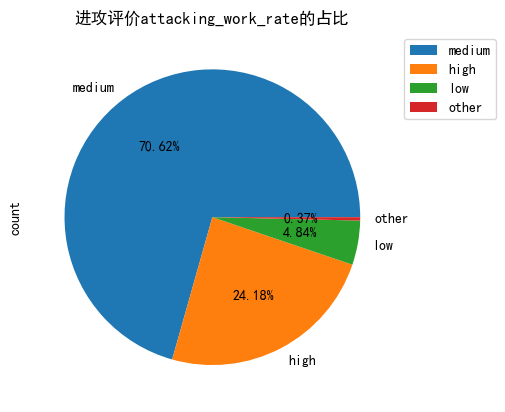

In [11]:
# 实战训练一饼图在足球数据集中的应用
# 需求说明
# 利用饼图统计球员评价记录中进攻评价attacking_work_rate的占比
df=pd.read_csv('../data/player_attributes.csv')
df
s=df.attacking_work_rate.value_counts().to_frame()
s
a=s.loc[['medium','high','low']]
a.loc['other']=s.loc[['norm','y','le','stoc']].sum()
a.plot.pie(y='count',radius=1,autopct='%.2f%%',title='进攻评价attacking_work_rate的占比')
plt.legend(bbox_to_anchor=(1,1))